# PROJECT QUESTIONS:
1. Which teams consistently outperform their expected goals (xG), and what might this suggest about their finishing ability?
2. How does possession percentage differ between wins, draws, and losses, and is possession actually associated with match success?
3. Does home-field advantage exist in the dataset, and how does team performance differ between home and away matches?
4. Which match statistics are most strongly associated with winning a game?

In [1]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('matches.csv')
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2020-09-21,20:15 (21:15),Premier League,Matchweek 2,Mon,Away,W,3,1,Wolves,1.9,0.6,65,NaN,Fernandinho,4-2-3-1,Andre Marriner,Match Report,NaN,13,8,21.1,2,1,1,2024,Manchester City
1,2,2020-09-27,16:30 (17:30),Premier League,Matchweek 3,Sun,Home,L,2,5,Leicester City,0.9,2.9,72,NaN,Fernandinho,4-2-3-1,Michael Oliver,Match Report,NaN,16,5,19.8,1,0,0,2024,Manchester City
2,4,2020-10-03,17:30 (18:30),Premier League,Matchweek 4,Sat,Away,D,1,1,Leeds United,1.2,2.4,49,NaN,Kevin De Bruyne,4-3-3,Mike Dean,Match Report,NaN,23,1,18.2,1,0,0,2024,Manchester City
3,5,2020-10-17,17:30 (18:30),Premier League,Matchweek 5,Sat,Home,W,1,0,Arsenal,1.3,0.9,58,NaN,Raheem Sterling,3-1-4-2,Chris Kavanagh,Match Report,NaN,13,5,17.7,0,0,0,2024,Manchester City
4,7,2020-10-24,12:30 (13:30),Premier League,Matchweek 6,Sat,Away,D,1,1,West Ham,1.0,0.3,69,NaN,Raheem Sterling,4-3-3,Anthony Taylor,Match Report,NaN,14,7,20.9,1,0,0,2024,Manchester City


## Clean data

In [3]:
#drop Unnamed: 0
df.drop('Unnamed: 0', axis=1, inplace=True)

In [4]:
#check for null values
df.isnull().sum()

date               0
time               0
comp               0
round              0
day                0
venue              0
result             0
gf                 0
ga                 0
opponent           0
xg                 0
xga                0
poss               0
attendance      1633
captain            0
formation          0
referee            0
match report       0
notes           4788
sh                 0
sot                0
dist               2
fk                 0
pk                 0
pkatt              0
season             0
team               0
dtype: int64

In [5]:
#drop notes, time, and attendance
df.drop(['notes', 'attendance', 'time'], axis=1, inplace=True)

In [6]:
#look at the rows with dist null values
df[df.dist.isnull()]

,date,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,captain,formation,referee,match report,sh,sot,dist,fk,pk,pkatt,season,team
498,2020-10-18,Premier League,Matchweek 5,Sun,Home,D,1,1,Brighton,0.8,1.7,34,Gary Cahill,4-4-2,Stuart Attwell,Match Report,0,0,NaN,0,1,1,2024,Crystal Palace
3766,2020-10-18,Premier League,Matchweek 5,Sun,Home,D,1,1,Brighton,0.8,1.7,34,Gary Cahill,4-4-2,Stuart Attwell,Match Report,0,0,NaN,0,1,1,2021,Crystal Palace


In [7]:
#drop index 498
df.drop(498, axis = 0, inplace = True)

In [8]:
#Filter df to only show rows with crystal palace in 2020
cp_2020 = df[(df.team == 'Crystal Palace') & (df.season == 2021)]

In [9]:
#Get the average distance for crystal palace in 2020
avg_dist_cp_2020 = cp_2020['dist'].mean()
#Replace the nan value with the average distance
df['dist'] = df['dist'].replace(np.nan, avg_dist_cp_2020)
df.iloc[[3765]]

,date,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,captain,formation,referee,match report,sh,sot,dist,fk,pk,pkatt,season,team
3766,2020-10-18,Premier League,Matchweek 5,Sun,Home,D,1,1,Brighton,0.8,1.7,34,Gary Cahill,4-4-2,Stuart Attwell,Match Report,0,0,17.486486,0,1,1,2021,Crystal Palace


In [10]:
#Round all values in dist column to one decimal point
df['dist'] = np.round(df['dist'], 1)

In [11]:
#Data summary
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4787 entries, 0 to 4787
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          4787 non-null   object 
 1   comp          4787 non-null   object 
 2   round         4787 non-null   object 
 3   day           4787 non-null   object 
 4   venue         4787 non-null   object 
 5   result        4787 non-null   object 
 6   gf            4787 non-null   int64  
 7   ga            4787 non-null   int64  
 8   opponent      4787 non-null   object 
 9   xg            4787 non-null   float64
 10  xga           4787 non-null   float64
 11  poss          4787 non-null   int64  
 12  captain       4787 non-null   object 
 13  formation     4787 non-null   object 
 14  referee       4787 non-null   object 
 15  match report  4787 non-null   object 
 16  sh            4787 non-null   int64  
 17  sot           4787 non-null   int64  
 18  dist          4787 non-null   flo

In [12]:
#remove match report and referee
df.drop(['match report', 'referee'], axis=1, inplace=True)

In [13]:
#change season dtype to object
df.season = df.season.astype('object')

In [14]:
#check if there are any duplicate values
df.duplicated().sum()

np.int64(0)

In [15]:
#Check if all teams have an observation of 38 games for each season
pd.set_option('display.max_rows', None)
match_count = df.groupby(['season', 'team']).size().reset_index(name = "match count")
match_count[match_count['match count'] > 38]

,season,team,match count
65,2023,Chelsea,76
70,2023,Leicester City,76
71,2023,Liverpool,76
72,2023,Manchester City,76
73,2023,Manchester United,76
77,2023,Tottenham Hotspur,76
80,2024,Arsenal,76
81,2024,Aston Villa,76
84,2024,Brighton and Hove Albion,76
85,2024,Burnley,76


In [16]:
#look into one of the teams with more observations
df[(df.season == 2024) & (df.team == 'Crystal Palace')].head()

,date,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,captain,formation,sh,sot,dist,fk,pk,pkatt,season,team
494,2020-09-12,Premier League,Matchweek 1,Sat,Home,W,1,0,Southampton,1.1,0.9,31,Scott Dann,4-4-2,5,3,10.6,0,0,0,2024,Crystal Palace
495,2020-09-19,Premier League,Matchweek 2,Sat,Away,W,3,1,Manchester Utd,1.6,1.2,25,Wilfried Zaha,4-4-2,13,4,18.6,0,1,1,2024,Crystal Palace
496,2020-09-26,Premier League,Matchweek 3,Sat,Home,L,1,2,Everton,0.4,1.9,42,Wilfried Zaha,4-4-2,8,1,18.3,0,0,0,2024,Crystal Palace
497,2020-10-03,Premier League,Matchweek 4,Sat,Away,L,0,4,Chelsea,0.2,2.7,30,Wilfried Zaha,4-4-2,4,0,22.5,0,0,0,2024,Crystal Palace
499,2020-10-24,Premier League,Matchweek 6,Sat,Away,W,2,1,Fulham,2.5,1.1,36,Luka Milivojević,4-4-2,14,10,11.9,1,0,0,2024,Crystal Palace


A lot of teams have more observations than they are supposed to. Looking at chelsea's match record in 2023, i can see that some observations are from season 2020. This also applies to other teams.

In [17]:
#Check if there are duplicates based on specific columns
df.duplicated(subset = ['date', 'team', 'opponent', 'result']).sum()

np.int64(987)

In [18]:
#Drop duplicates based on specific columns. Keep the last observation cause the order of the dataset is in descending order.
df = df.drop_duplicates(subset=['date', 'team', 'opponent', 'result'], keep='last')
#Check if there are duplicates based on specific columns
df.duplicated(subset = ['date', 'team', 'opponent', 'result']).sum()

np.int64(0)

In [19]:
#Check if all teams have an observation of 38 games for each season
pd.set_option('display.max_rows', None)
match_count = df.groupby(['season', 'team']).size().reset_index(name = "match count")
match_count[match_count['match count'] > 38]

,season,team,match count


## EXPLORATORY ANALYSIS

In [20]:
#Statistical summary
df.describe()

,gf,ga,xg,xga,poss,sh,sot,dist,fk,pk,pkatt
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,1.436579,1.436579,1.394789,1.394789,50.001053,12.607895,4.232632,17.260368,0.437105,0.112632,0.138421
std,1.298623,1.298623,0.827473,0.827473,12.767692,5.563999,2.463546,3.028020,0.655623,0.334784,0.369682
min,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,5.300000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.800000,0.800000,40.000000,9.000000,2.000000,15.300000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.300000,1.300000,50.000000,12.000000,4.000000,17.100000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,1.900000,1.900000,60.000000,16.000000,6.000000,19.000000,1.000000,0.000000,0.000000
max,9.000000,9.000000,7.000000,7.000000,82.000000,36.000000,15.000000,39.900000,4.000000,3.000000,3.000000


## 1. Which teams consistently outperform their expected goals (xG), and what might this suggest about their finishing ability?

In [21]:
#find out how many seasons are here
print(f'There are {df.season.nunique()} seasons.')

There are 5 seasons.


In [22]:
# Group data by season and team, sum stats, keep only goals for (gf) and expected goals (xg)
team_goals_stats = df.groupby(['season', 'team']).sum()[['gf', 'xg']].reset_index()
# Calculate goal difference (actual goals minus expected goals) for each team/season
team_goals_stats['goal_diff'] = team_goals_stats['gf'] - team_goals_stats['xg']

Teams that outperformed their expected goals and how many seasons they did: 
                        Team  Season  Total_Goal_Diff
0           Manchester City       5             65.9
1                   Arsenal       5             44.0
2         Tottenham Hotspur       5             54.5
3               Aston Villa       4             23.7
4          Newcastle United       4             19.6
5           West Ham United       4             22.9
6            Crystal Palace       4             19.7
7                 Liverpool       4             25.3
8            Leicester City       4             31.3
9         Manchester United       4             18.7
10  Wolverhampton Wanderers       2              3.5
11                  Everton       2              3.0
12                  Chelsea       2             15.3
13                   Fulham       2             12.9
14                Brentford       2              3.7
15             Leeds United       2              7.0
16               Luto

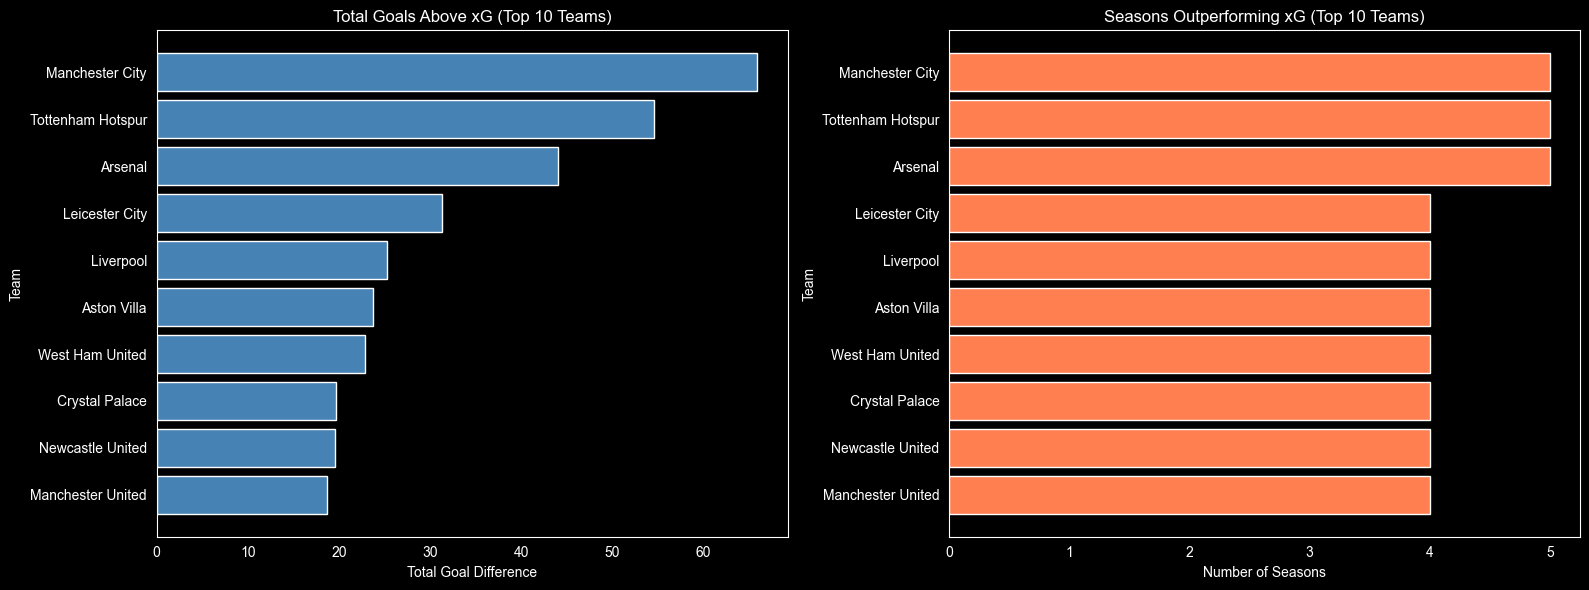

<Figure size 640x480 with 0 Axes>

In [38]:
# Filter to only rows where the team outperformed their expected goals (goal_diff > 0)
# Sort by season, then by goal_diff in descending order
positive_goal_diff = team_goals_stats[team_goals_stats['goal_diff'] > 0].sort_values(['season', 'goal_diff'], ascending=False)
# Group the outperforming seasons by team and sum their goal_diff to get total goal difference per team
total_goal_diff = positive_goal_diff.groupby('team')['goal_diff'].sum().reset_index()
total_goal_diff.columns = ['Team', 'Total_Goal_Diff']
# Count how many seasons each team appears in (i.e., how many seasons they outperformed expected goals)
consistent_outperformers = positive_goal_diff['team'].value_counts().reset_index()
consistent_outperformers.columns = ['Team', 'Season']
# Merge the total goal difference into the consistent_outperformers DataFrame
consistent_outperformers = consistent_outperformers.merge(total_goal_diff, on='Team')
#Display
print(f"Teams that outperformed their expected goals and how many seasons they did: \n {consistent_outperformers}")

# Sort by total goal difference and keep top 10 for readability
top_10 = consistent_outperformers.sort_values('Total_Goal_Diff', ascending=False).head(10)

# Plot horizontal bar chart of total goal difference above xG per team
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plot Total goal difference above xG
axes[0].barh(top_10['Team'], top_10['Total_Goal_Diff'], color='steelblue')
axes[0].set_title('Total Goals Above xG (Top 10 Teams)')
axes[0].set_xlabel('Total Goal Difference')
axes[0].set_ylabel('Team')
axes[0].invert_yaxis()
axes[0].grid(False)

#Plot Number of seasons each team outperformed xG
axes[1].barh(top_10['Team'], top_10['Season'], color='coral')
axes[1].set_title('Seasons Outperforming xG (Top 10 Teams)')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('Team')
axes[1].invert_yaxis()
axes[1].grid(False)

plt.tight_layout()
plt.show()
plt.clf()

Manchester City stand out as the most consistent overperformers relative to expected goals, accumulating a total of 65.9 goals above xG across all 5 seasons- roughly 13 more than expected per season- suggesting their attackers are exceptionally clinical in front of goal.

## 2. How does possession percentage differ between wins, draws, and losses, and is possession actually associated with match success?


### Find out the correlation between results and poss

In [39]:
#Since result is a categorical variable, I'll create a new column called points to assign a numeric value to each result, allowing me to assess the correlation between match result and possession.
df['points'] = df.result.map({'W': 3, 'L': 0, 'D': 1})
df[['points', 'poss']].corr()

,points,poss
points,1.000000,0.154259
poss,0.154259,1.000000


The correlation between possession and points is 0.15, indicating an extremely weak positive relationship, which confirms that possession alone has little to no association with match success.

### Plot a bar graph showing the average possession for each result

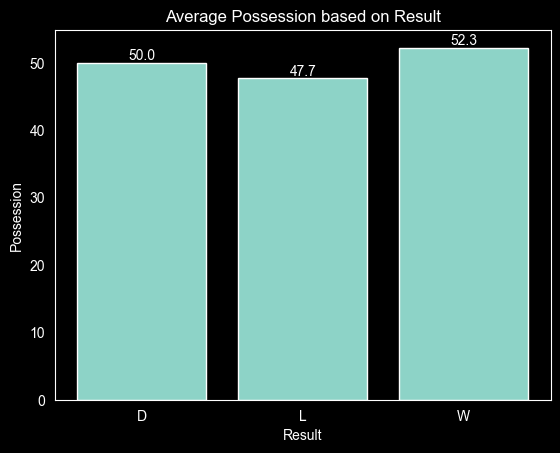

<Figure size 640x480 with 0 Axes>

In [40]:
def avg_poss_by_result(df, season = None, team = None):
    #Calculate average possession percentage for each result (W/D/L)
    avg_poss_result = df.groupby('result')['poss'].mean()
    #plot bar and save it to variable
    bars = plt.bar(avg_poss_result.index, avg_poss_result.values)
    #Add possession values on top of each bar rounded to 1 decimal place
    plt.bar_label(bars, fmt='%.1f')

    #Build title dynamically depending on what filters were applied
    if team and season:
        title = f'{team} Average Possession based on Result in {season}'
    elif team:
        title = f'{team} Average Possession based on Result'
    else:
        title = 'Average Possession based on Result'

    plt.title(title)
    plt.xlabel("Result")
    plt.ylabel("Possession")
    plt.grid(False)
    plt.show()
    plt.clf()
#Call function
avg_poss_by_result(df)

Teams that win tend to have higher average possession, while losses are associated with lower possession though the weak correlation suggests this relationship isn't causal

### Show the average possession for manchester city in season 2024

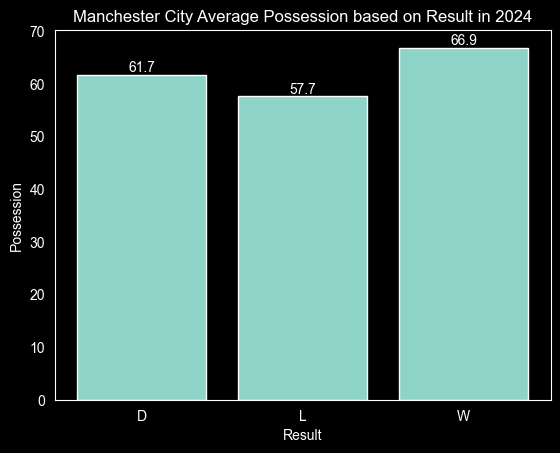

<Figure size 640x480 with 0 Axes>

In [41]:
#Filter the df to show only the input season and team
team_df = df[(df.team == 'Manchester City') & (df.season == 2024)]
#get average possession by result based on season and team
avg_poss_by_result(team_df, 2024, 'Manchester City')

## 3. Does home-field advantage exist in the dataset, and how does team performance differ between home and away matches?

Home and Away Performance Metrics: 
              gf        ga       poss        xg
venue                                         
Away   1.310000  1.563158  49.051053  1.266053
Home   1.563158  1.310000  50.951053  1.523526


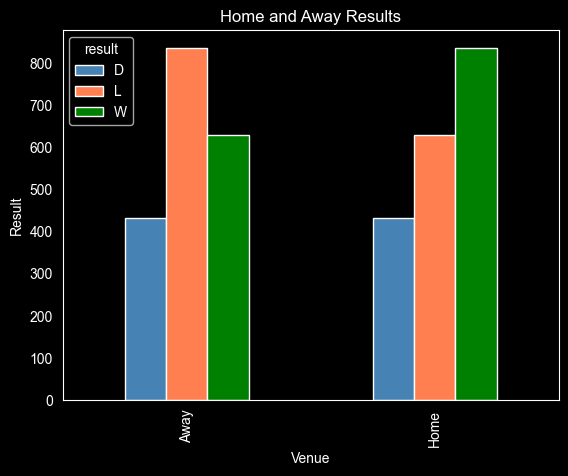

<Figure size 640x480 with 0 Axes>

In [29]:
#group df by venue and result and count how many rows fall into each category then visualize
def home_away_advantage(df, team = None, season = None):
    #group df by venue and find the average of some performance metrics
    ha_performance = df.groupby('venue')[['gf', 'ga', 'poss', 'xg']].mean()
    print(f"Home and Away Performance Metrics: \n {ha_performance}")

    #Count results per venue and unstack to get W/D/L as columns
    ha_result = df.groupby(['venue', 'result']).size().unstack()
    ha_result.plot(kind='bar', color=['steelblue', 'coral', 'green'])

    #Build title dynamically depending on what filters were applied
    if team and season:
        title = f'{team} Home and Away Results in {season}'
    elif team:
        title = f'{team} Home and Away Results'
    else:
        title = 'Home and Away Results'

    #plot
    plt.title(title)
    plt.xlabel('Venue')
    plt.ylabel('Result')
    plt.grid(False)
    plt.show()
    plt.clf()
#call function
home_away_advantage(df)

Home field advantage does exist in this dataset, with the bar chart clearly showing more home wins across all teams. This is further reflected in the performance metrics, where home matches generally produce better numbers across goals scored, possession, and expected goals while goals against is the only metric that favours away matches.

Home and Away Performance Metrics: 
              gf        ga       poss        xg
venue                                         
Away   2.157895  0.863158  64.421053  2.064211
Home   2.831579  0.821053  66.631579  2.231579


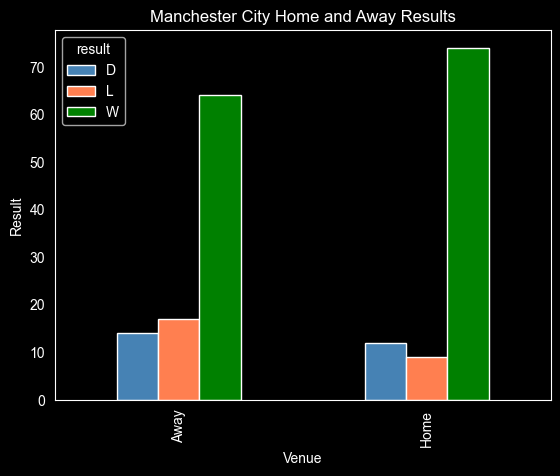

<Figure size 640x480 with 0 Axes>

In [30]:
#Look into a particular team
team_df = df[df.team == 'Manchester City']
#Find out how the team performance differs based on venue & get teams home and away record and visualize it
home_away_advantage(team_df, 'Manchester City')

Using Manchester City as an example, they are very consistent home and away.

Home and Away Performance Metrics: 
              gf        ga       poss        xg
venue                                         
Away   2.368421  0.947368  63.473684  2.105263
Home   2.684211  0.842105  66.947368  2.136842


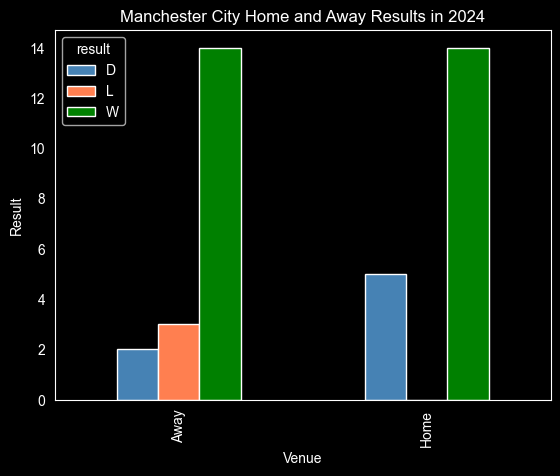

<Figure size 640x480 with 0 Axes>

In [31]:
#Look into a particular team in a season
season_team_df = df[(df['team'] == 'Manchester City') & (df['season'] == 2024)]
#Find out how the team performance differs based on venue & get teams home and away record and visualize it
home_away_advantage(season_team_df, 'Manchester City', 2024)

In 2024, Manchester City remained unbeaten at home and matched their home win tally away from home, highlighting their consistency regardless of venue. This is further supported by their performance metrics, which are nearly identical home and away — with goals against being marginally higher on the road, though the difference isn't much.

## 4. Which match statistics are most strongly associated with winning a game?
Since we made a points column that keeps track of how many points a team gets based on result, we would use that to find correlations.

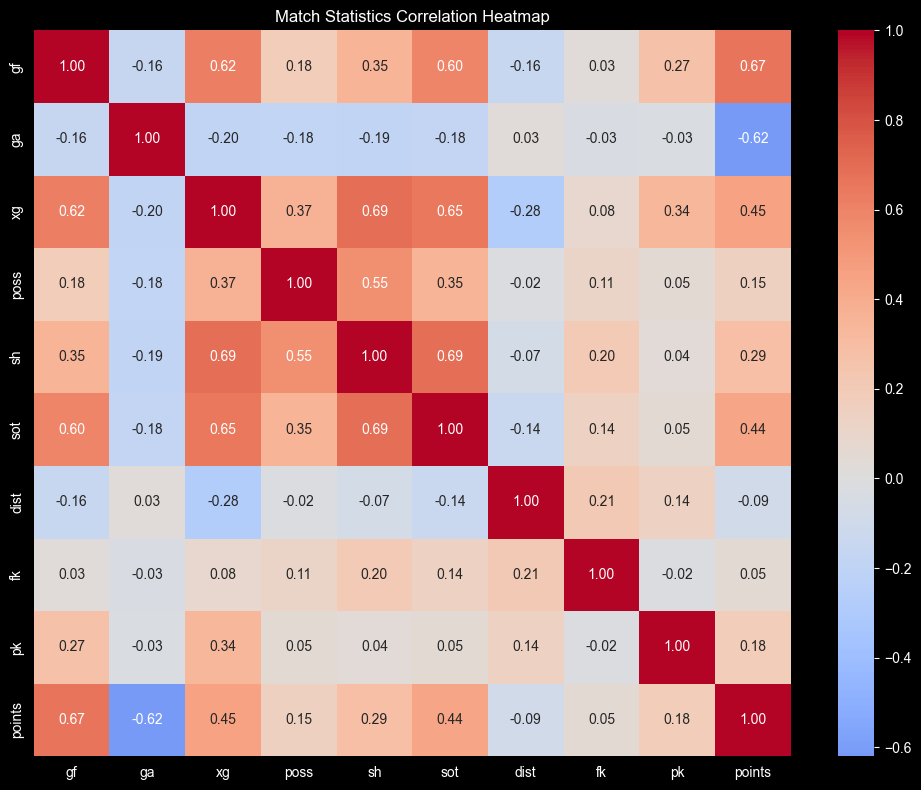

<Figure size 640x480 with 0 Axes>

In [33]:
#Calculate correlation matrix for all selected match statistics
corr_matrix = df[['gf', 'ga', 'xg', 'poss', 'sh', 'sot', 'dist', 'fk', 'pk', 'points']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Match Statistics Correlation Heatmap')
plt.tight_layout()
plt.show()
plt.clf()

The match statistics most strongly associated with winning a game are Goals For (GF) and Goals Against (GA). Goals For has a strong positive correlation with points, indicating that teams that score more goals are more likely to win matches. Conversely, Goals Against has a strong negative correlation with points, suggesting that teams that concede more goals are less likely to achieve positive results. These findings are expected since goals directly determine match outcomes. However, aside from these two variables, no other match statistic exhibits a strong correlation with winning, indicating that factors such as possession, shots, and other performance metrics have a weaker direct relationship with match results.